In [67]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [68]:
#%pip install -e ..

In [69]:
from proj2dhullsampler import Prep_Mask_Generation
from proj2dhullsampler.prep_class import meta_one_hot_shot

In [70]:
obs = xr.open_dataset('/glade/work/fanda/miles-climatesleuth/microphysics_analysis/data/satellite_climatologies_withuncertainty360nlon180nlat_updatedMar2026.nc')
obs = obs.mean(dim = "mos").sel(obstype = 1)
obs['pr'] = obs['pr']/(1000 * 86400)

In [71]:
working_dir = '/glade/work/qingyuany/camml_re'
case_name = "v4_extreme"


obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "tlwp", "TMQ": "pwv",
          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}


In [72]:
ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v3_extreme/post_simulations/batch_filter_v3.nc")

In [73]:
obs_interp = obs.interp(
    lat=ppe["lat"],
    lon=ppe["lon"]
)

obs_interp = obs_interp[list(obs_dict.values())]
obs_interp = obs_interp.drop_vars('obstype')

In [74]:
obs_interp

<xarray.Dataset> Size: 3MB
Dimensions:    (lat: 192, lon: 288)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    swcrf_toa  (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    lwcrf_toa  (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    tlwp       (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    pwv        (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    olr        (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    pr         (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    swabs_toa  (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan

In [75]:
para = pd.read_csv("/glade/work/qingyuany/camml_re/v3_extreme/post_simulations/post_paras.csv", index_col=0)
para.head()



,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
1,8.764451e+09,0.734829,0.504504,0.660242,0.583751,0.000041,0.000231,2.397564,4.297589,0.520757,...,101.458370,0.642010,0.440628,0.224962,0.838330,0.102638,0.147649,4.601857,3.895177,2.947053
2,6.249091e+09,0.719602,0.451698,0.623707,4.913654,0.000178,0.000216,2.094584,3.640743,0.392219,...,89.033010,1.147832,0.284604,0.790406,0.334195,0.078667,0.133590,3.908127,2.368320,2.932574
3,3.643257e+09,0.734745,0.631602,0.602616,3.506507,0.000058,0.000234,2.936606,4.589038,0.647695,...,74.284987,1.691183,0.121225,0.210095,0.945064,0.183940,0.022292,2.124240,2.945122,1.680474
4,7.799491e+09,0.867221,0.449595,0.698135,3.682035,0.000031,0.000236,0.483083,3.766823,0.356188,...,76.816492,1.891392,0.760065,0.800012,0.472317,0.240086,0.186566,2.662161,2.162034,1.920328
5,3.249013e+09,0.996169,0.395150,0.731877,7.910945,0.000163,0.000216,2.104301,4.542901,0.281722,...,98.345530,1.820523,0.252576,0.662260,0.698986,0.479244,0.034171,2.748193,4.844915,1.837668


In [76]:

obs_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v0/filtered_obs_precip_freq.csv', index_col = 0)
obs_precip_freq = obs_precip_freq.iloc[:,0]

ppe_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v3_extreme/post_simulations/filtered_extreme_precip.csv', index_col=0)

In [77]:
ppe_precip_freq

,filter_precip099,filter_precip0999,filter_precip09999
1,373.533346,503.158143,625.515229
2,375.951889,513.124566,627.941763
3,376.102260,518.649713,636.266978
4,366.566361,493.989113,595.864959
5,400.901404,546.963794,665.939865
...,...,...,...
96,402.632969,538.313260,665.171162
97,420.002607,579.685060,719.637508
98,338.496496,456.733961,577.270153
99,413.740035,570.667076,690.836907


In [78]:
lat_bins = np.arange(-75, 76, 10)  # -90 to 90 every 10 degrees

In [79]:
lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))

In [80]:
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359


In [81]:
weights = np.cos(np.deg2rad(obs_interp.lat))
weights = weights / weights.mean()


ppe_global = ppe[['SWCF', 'LWCF', 'FLUT', 'FSNTOA']].weighted(weights).mean(dim = ["lat", "lon"]).to_dataframe()
obs_global = obs_interp[['swcrf_toa', 'lwcrf_toa', 'olr', 'swabs_toa']].weighted(weights).mean(dim = ["lat", "lon"]).to_array().to_series()

ppe_global.columns = ['ave_SWCF', 'ave_LWCF', 'ave_FLUT', 'ave_FSNTOA'] 
obs_global.index = ['ave_SWCF', 'ave_LWCF', 'ave_FLUT', 'ave_FSNTOA'] 

In [82]:
ppe_global = pd.concat([ppe_global, ppe_precip_freq], axis = 1)
obs_global = pd.concat([obs_global, obs_precip_freq])

In [83]:
test_case = Prep_Mask_Generation(working_dir, case_name, ppe, 
                                 obs_interp, obs_dict, para, lat_bins, manul_ppe_info, 
                                 added_ppe_obs=[ppe_global, obs_global])

Parameter and simulation indices match
nan variables matching between obs and simulation
Added data index matching
Zonalized and manually selected obs and ppe written as csv


In [84]:
test_case.sensitivity_emulation(n_cpus = 10)

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [85]:
test_case.mask_generation(threshold_level=2.0)


In [86]:
test_case.mask_generation(threshold_level=2.5)
test_case.mask_generation(threshold_level=3.0)

In [87]:
meta_table = meta_one_hot_shot(test_case.meta, test_case.data_gcm.para_nm)

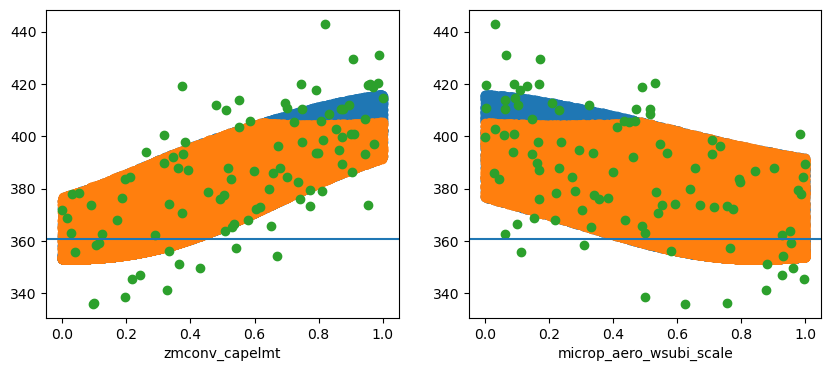

In [91]:
test_case.visualize_check('filter_precip099')

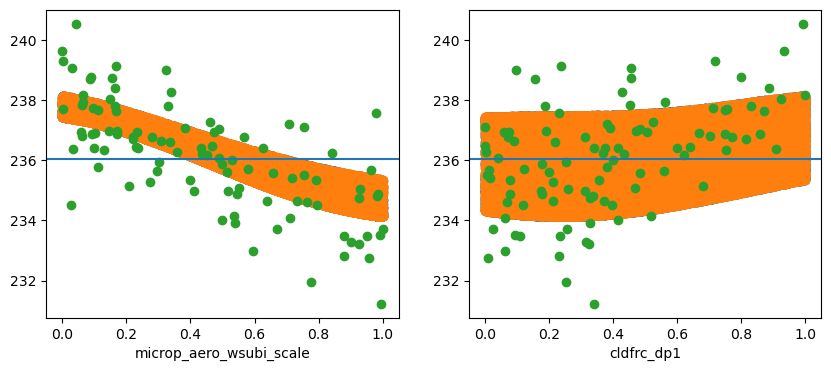

In [89]:
test_case.visualize_check('FLUT_zonal_35to45')

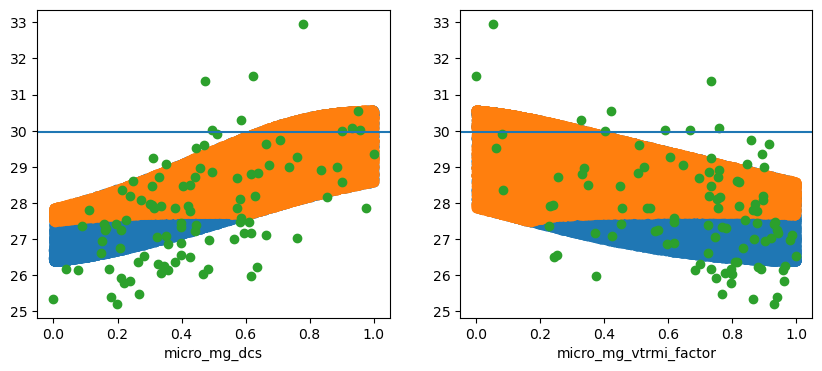

In [45]:
test_case.visualize_check('LWCF_zonal_-55to-45')

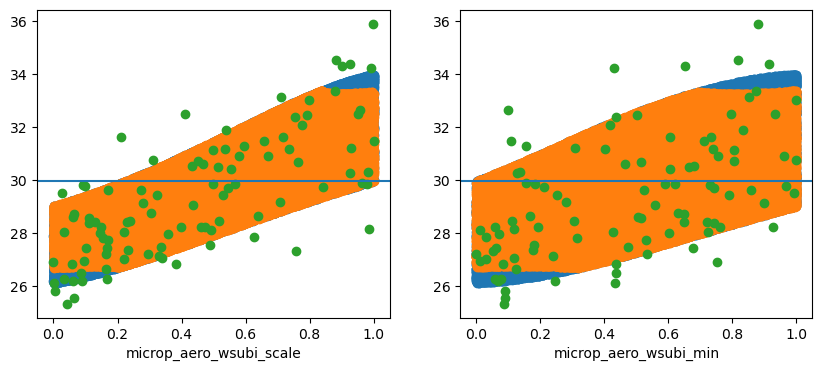

In [90]:
test_case.visualize_check('LWCF_zonal_-55to-45')